In [1]:
import pandas as pd
import xarray as xr

# Load the NetCDF file
nc_file = '9ebd0234ce2404cdd06406436a6ab545.nc'
ds = xr.open_dataset(nc_file)

df = ds.to_dataframe().reset_index()

# Preview the data
print(df.head())

# Save as CSV for your parametric insurance analysis
df.to_csv('9ebd0234ce2404cdd06406436a6ab545.csv', index=False)
print('Successfully converted NetCDF to 9ebd0234ce2404cdd06406436a6ab545.csv!')

  valid_time  latitude  longitude        ssrd  number expver
0 2005-01-01      23.1       72.5  17106796.0       0   0001
1 2005-01-01      23.1       72.6  17089220.0       0   0001
2 2005-01-01      23.1       72.7  17088788.0       0   0001
3 2005-01-01      23.0       72.5  17162068.0       0   0001
4 2005-01-01      23.0       72.6  17145704.0       0   0001
Successfully converted NetCDF to 9ebd0234ce2404cdd06406436a6ab545.csv!


In [2]:
import pandas as pd

df = pd.read_csv("9ebd0234ce2404cdd06406436a6ab545.csv")

print(df.head())

   valid_time  latitude  longitude        ssrd  number  expver
0  2005-01-01      23.1       72.5  17106796.0       0       1
1  2005-01-01      23.1       72.6  17089220.0       0       1
2  2005-01-01      23.1       72.7  17088788.0       0       1
3  2005-01-01      23.0       72.5  17162068.0       0       1
4  2005-01-01      23.0       72.6  17145704.0       0       1


In [3]:
# Filter for Pincode 380006 nearest grid point (Lat: 23.0, Lon: 72.6)

df_clean = df[(df["latitude"] == 23.0) & (df["longitude"] == 72.6)].copy()
df_clean["valid_time"] = pd.to_datetime(df_clean["valid_time"])

print(df_clean.head())

# Purpose: Keep only the weather observations corresponding to the selected location.

   valid_time  latitude  longitude        ssrd  number  expver
4  2005-01-01      23.0       72.6  17145704.0       0       1
10 2005-02-01      23.0       72.6  20543984.0       0       1
16 2005-03-01      23.0       72.6  23844896.0       0       1
22 2005-04-01      23.0       72.6  26904104.0       0       1
28 2005-05-01      23.0       72.6  27018098.0       0       1


In [4]:
# Unit Conversion (J/m² to kWh/m²/day)

df_clean["irradiance_kwh_m2_day"] = df_clean["ssrd"] / 3_600_000.0

print(df_clean.head())

# Purpose: Convert radiation into a usable unit for solar energy calculations.

   valid_time  latitude  longitude        ssrd  number  expver  \
4  2005-01-01      23.0       72.6  17145704.0       0       1   
10 2005-02-01      23.0       72.6  20543984.0       0       1   
16 2005-03-01      23.0       72.6  23844896.0       0       1   
22 2005-04-01      23.0       72.6  26904104.0       0       1   
28 2005-05-01      23.0       72.6  27018098.0       0       1   

    irradiance_kwh_m2_day  
4                4.762696  
10               5.706662  
16               6.623582  
22               7.473362  
28               7.505027  


In [5]:
# Solar Generation Modeling (3 kVA capacity, 80% PR)
CAPACITY = 3.0  # kVA
PR = 0.80  # 80% Performance Ratio

df_clean["daily_gen_kwh"] = CAPACITY * df_clean["irradiance_kwh_m2_day"] * PR

df_clean["days_in_month"] = df_clean["valid_time"].dt.days_in_month

df_clean["monthly_gen_kwh"] = (df_clean["daily_gen_kwh"] * df_clean["days_in_month"])

print(df_clean.head())

# Purpose: Estimate the monthly electricity generation from rooftop solar.

   valid_time  latitude  longitude        ssrd  number  expver  \
4  2005-01-01      23.0       72.6  17145704.0       0       1   
10 2005-02-01      23.0       72.6  20543984.0       0       1   
16 2005-03-01      23.0       72.6  23844896.0       0       1   
22 2005-04-01      23.0       72.6  26904104.0       0       1   
28 2005-05-01      23.0       72.6  27018098.0       0       1   

    irradiance_kwh_m2_day  daily_gen_kwh  days_in_month  monthly_gen_kwh  
4                4.762696      11.430469             31       354.344549  
10               5.706662      13.695989             28       383.487701  
16               6.623582      15.896597             31       492.794517  
22               7.473362      17.936069             30       538.082080  
28               7.505027      18.012065             31       558.374025  


In [6]:
# Save cleaned dataset
df_clean.to_csv("clean_solar_data_380006.csv", index=False)
print("Data cleaning and conversion complete!")

Data cleaning and conversion complete!


In [7]:
df_clean

,valid_time,latitude,longitude,ssrd,number,expver,irradiance_kwh_m2_day,daily_gen_kwh,days_in_month,monthly_gen_kwh
4,2005-01-01,23.0,72.6,17145704.0,0,1,4.762696,11.430469,31,354.344549
10,2005-02-01,23.0,72.6,20543984.0,0,1,5.706662,13.695989,28,383.487701
16,2005-03-01,23.0,72.6,23844896.0,0,1,6.623582,15.896597,31,492.794517
22,2005-04-01,23.0,72.6,26904104.0,0,1,7.473362,17.936069,30,538.082080
28,2005-05-01,23.0,72.6,27018098.0,0,1,7.505027,18.012065,31,558.374025
...,...,...,...,...,...,...,...,...,...,...
1414,2024-08-01,23.0,72.6,11639942.0,0,1,3.233317,7.759961,31,240.558801
1420,2024-09-01,23.0,72.6,15224486.0,0,1,4.229024,10.149657,30,304.489720
1426,2024-10-01,23.0,72.6,17748570.0,0,1,4.930158,11.832380,31,366.803780
1432,2024-11-01,23.0,72.6,17996684.0,0,1,4.999079,11.997789,30,359.933680


In [8]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 4 to 1438
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   valid_time             240 non-null    datetime64[us]
 1   latitude               240 non-null    float64       
 2   longitude              240 non-null    float64       
 3   ssrd                   240 non-null    float64       
 4   number                 240 non-null    int64         
 5   expver                 240 non-null    int64         
 6   irradiance_kwh_m2_day  240 non-null    float64       
 7   daily_gen_kwh          240 non-null    float64       
 8   days_in_month          240 non-null    int32         
 9   monthly_gen_kwh        240 non-null    float64       
dtypes: datetime64[us](1), float64(6), int32(1), int64(2)
memory usage: 17.9 KB


In [9]:
import numpy as np
import pandas as pd

df_clean = pd.read_csv("clean_solar_data_380006.csv")
df_clean["valid_time"] = pd.to_datetime(df_clean["valid_time"])

df_clean.head()

,valid_time,latitude,longitude,ssrd,number,expver,irradiance_kwh_m2_day,daily_gen_kwh,days_in_month,monthly_gen_kwh
0,2005-01-01,23.0,72.6,17145704.0,0,1,4.762696,11.430469,31,354.344549
1,2005-02-01,23.0,72.6,20543984.0,0,1,5.706662,13.695989,28,383.487701
2,2005-03-01,23.0,72.6,23844896.0,0,1,6.623582,15.896597,31,492.794517
3,2005-04-01,23.0,72.6,26904104.0,0,1,7.473362,17.936069,30,538.082080
4,2005-05-01,23.0,72.6,27018098.0,0,1,7.505027,18.012065,31,558.374025


In [23]:
df_clean["year"] = df_clean["valid_time"].dt.year

df_clean.head()

,valid_time,latitude,longitude,ssrd,number,expver,irradiance_kwh_m2_day,daily_gen_kwh,days_in_month,monthly_gen_kwh,year
0,2005-01-01,23.0,72.6,17145704.0,0,1,4.762696,11.430469,31,354.344549,2005
1,2005-02-01,23.0,72.6,20543984.0,0,1,5.706662,13.695989,28,383.487701,2005
2,2005-03-01,23.0,72.6,23844896.0,0,1,6.623582,15.896597,31,492.794517,2005
3,2005-04-01,23.0,72.6,26904104.0,0,1,7.473362,17.936069,30,538.082080,2005
4,2005-05-01,23.0,72.6,27018098.0,0,1,7.505027,18.012065,31,558.374025,2005


In [10]:
# Calculate annual solar generation

df_clean["year"] = df_clean["valid_time"].dt.year

annual = (
    df_clean.groupby("year")["monthly_gen_kwh"]
    .sum()
    .reset_index()
)

annual

,year,monthly_gen_kwh
0,2005,4766.133391
1,2006,4638.716580
2,2007,4708.535655
3,2008,4662.357909
4,2009,4826.441213
5,2010,4681.133875
6,2011,4575.000736
7,2012,4722.337005
8,2013,4540.345620
9,2014,4752.746305


In [11]:
# Define insurance trigger and calculate payouts

AEP50 = 4600.0
TARIFF = 5.75

annual["shortfall_kwh"] = np.maximum(
    0,
    AEP50 - annual["monthly_gen_kwh"]
)

annual["payout_inr"] = (
    annual["shortfall_kwh"] * TARIFF
)

annual

,year,monthly_gen_kwh,shortfall_kwh,payout_inr
0,2005,4766.133391,0.000000,0.000000
1,2006,4638.716580,0.000000,0.000000
2,2007,4708.535655,0.000000,0.000000
3,2008,4662.357909,0.000000,0.000000
4,2009,4826.441213,0.000000,0.000000
5,2010,4681.133875,0.000000,0.000000
6,2011,4575.000736,24.999264,143.745768
7,2012,4722.337005,0.000000,0.000000
8,2013,4540.345620,59.654380,343.012685
9,2014,4752.746305,0.000000,0.000000


In [12]:
# Years in which the insurance trigger was activated

trigger_years = annual[annual["payout_inr"] > 0]

print(f"Total Years Analysed: {len(annual)}")
print(f"Trigger Activated: {len(trigger_years)} years")

trigger_years

# this tells - Historically, how often would this insurance policy have paid a claim?

Total Years Analysed: 20
Trigger Activated: 8 years


,year,monthly_gen_kwh,shortfall_kwh,payout_inr
6,2011,4575.000736,24.999264,143.745768
8,2013,4540.345620,59.654380,343.012685
11,2016,4583.447575,16.552425,95.176446
14,2019,4527.900365,72.099635,414.572899
16,2021,4550.448260,49.551740,284.922505
17,2022,4354.426879,245.573121,1412.045448
18,2023,3333.871277,1266.128723,7280.240155
19,2024,4360.471167,239.528833,1377.290792


insight:

Total years analyzed: 20 (2005–2024)

Trigger activated: 8 years

Trigger not activated: 12 years

This means the policy would have paid claims in 40% of the historical years.

In [13]:
# Back-testing summary

print(f"Average Annual Generation: {annual['monthly_gen_kwh'].mean():.2f} kWh")

print(f"Lowest Annual Generation: {annual['monthly_gen_kwh'].min():.2f} kWh")

print(f"Highest Annual Generation: {annual['monthly_gen_kwh'].max():.2f} kWh")

Average Annual Generation: 4566.88 kWh
Lowest Annual Generation: 3333.87 kWh
Highest Annual Generation: 4826.44 kWh


The average generation (4566.88 kWh) is actually slightly below the trigger (4600 kWh).

That's why the trigger was activated in 8 out of 20 years (40%).

In [14]:
# Best and worst performing years

best_year = annual.loc[annual["monthly_gen_kwh"].idxmax()]
worst_year = annual.loc[annual["monthly_gen_kwh"].idxmin()]

print("Best Performing Year")
print(best_year)

print("\nWorst Performing Year")
print(worst_year)

# Which historical year had the highest payout?
# Which year produced the most electricity?

Best Performing Year
year               2009.000000
monthly_gen_kwh    4826.441213
shortfall_kwh         0.000000
payout_inr            0.000000
Name: 4, dtype: float64

Worst Performing Year
year               2023.000000
monthly_gen_kwh    3333.871277
shortfall_kwh      1266.128723
payout_inr         7280.240155
Name: 18, dtype: float64


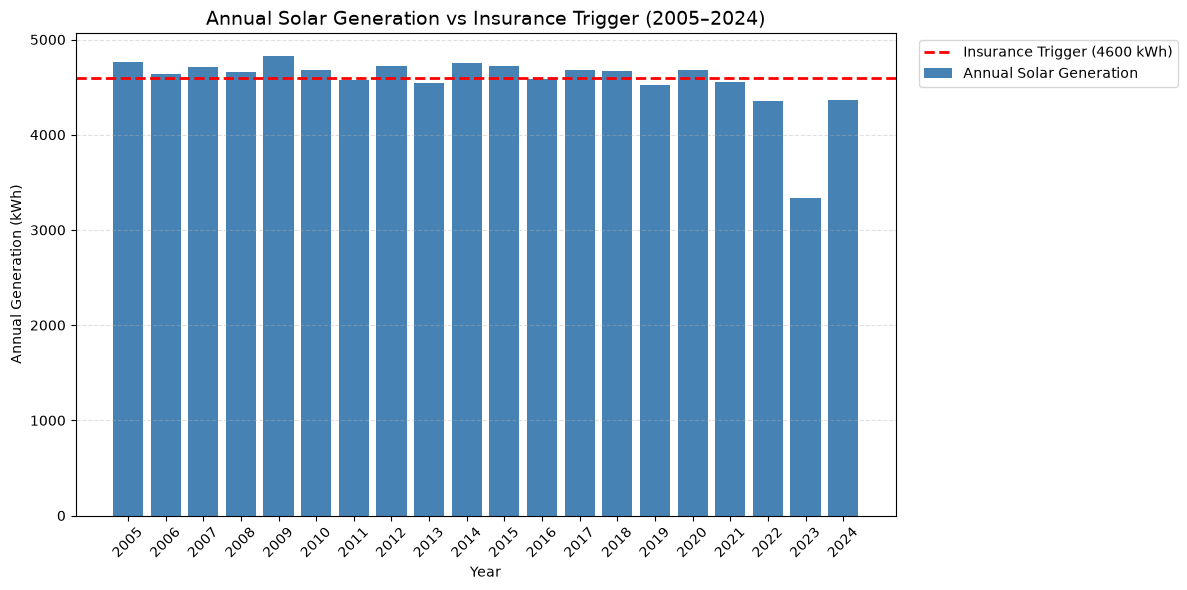

In [15]:
import matplotlib.pyplot as plt

# Ensure years are displayed as integers
annual["year"] = annual["year"].astype(int)

plt.figure(figsize=(12,6))

# Annual Generation Bars
plt.bar(
    annual["year"],
    annual["monthly_gen_kwh"],
    color="steelblue",
    label="Annual Solar Generation"
)

# Insurance Trigger Line
plt.axhline(
    y=AEP50,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Insurance Trigger ({AEP50:.0f} kWh)"
)

# Formatting
plt.title("Annual Solar Generation vs Insurance Trigger (2005–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Annual Generation (kWh)")

plt.xticks(annual["year"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Legend outside the chart
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


# Annual Solar Generation (2005–2024) with the Insurance Trigger (4600 kWh)
# Que - "Why did payouts occur?"

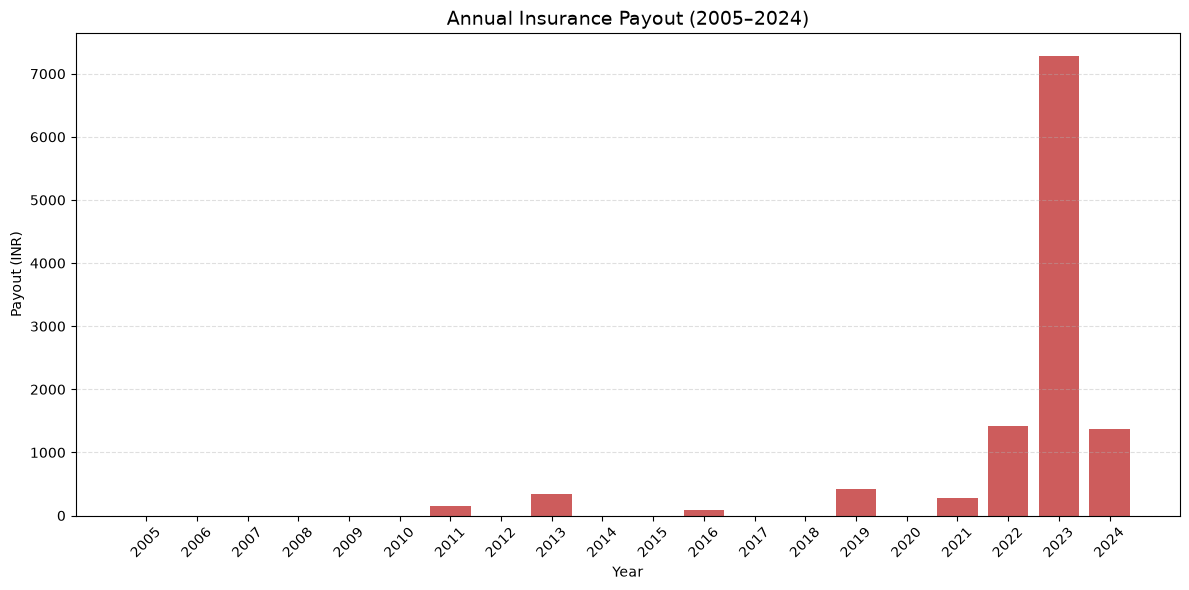

In [16]:
# "How much would the insurer have paid each year?"
# Annual Insurance Payout

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    annual["year"],
    annual["payout_inr"],
    color="indianred"
)

plt.title("Annual Insurance Payout (2005–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Payout (INR)")

plt.xticks(annual["year"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Monthly Solar Generation Trend (2005–2024)

1. It shows seasonality.
2. It proves the insurance index is based on weather.
3. It demonstrates your understanding of the underlying data.

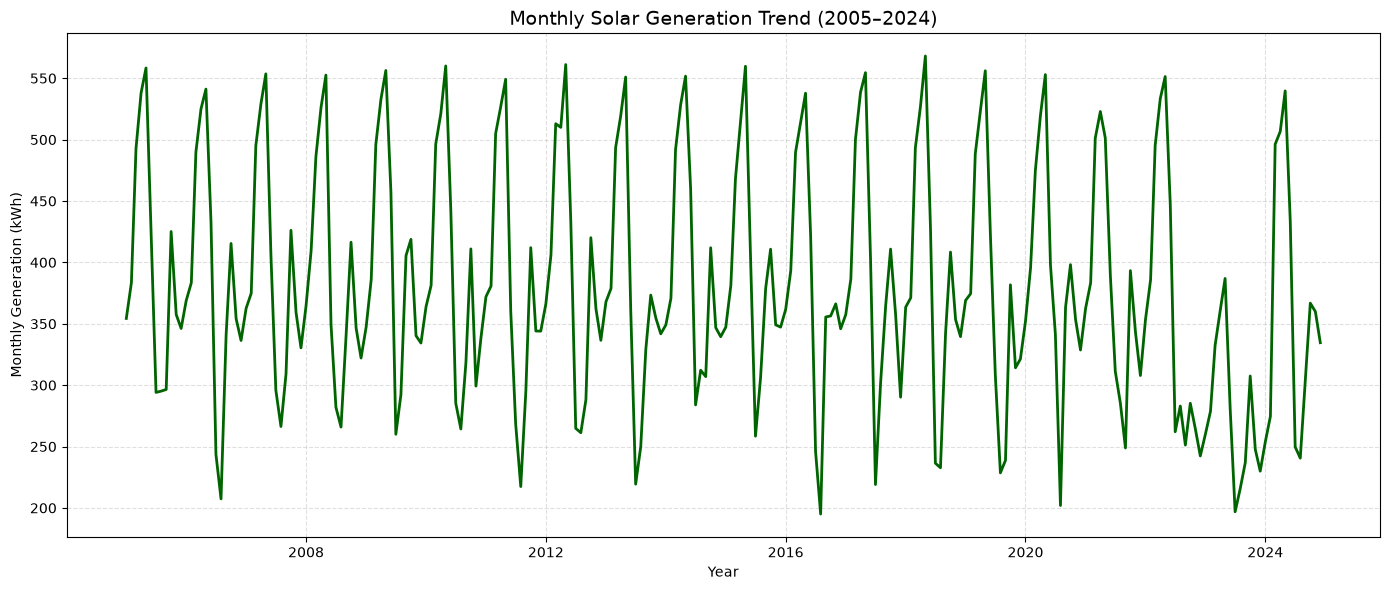

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df_clean["valid_time"],
    df_clean["monthly_gen_kwh"],
    color="darkgreen",
    linewidth=2
)

plt.title("Monthly Solar Generation Trend (2005–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Monthly Generation (kWh)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Model Assumptions

Solar Capacity: 3 kVA residential rooftop PV system

Performance Ratio (PR): 80%

AEP50 Trigger: 4,600 kWh/year

Electricity Tariff: ₹5.75/kWh

Administrative Loading: 20%

Risk Loading: 15%

In [18]:
# Insurance Pricing (Burn Cost Method)

burn_cost = annual["payout_inr"].mean()

admin_loading = 0.20      # 20%
risk_loading = 0.15       # 15%

commercial_premium = burn_cost * (
    1 + admin_loading + risk_loading
)

print(f"Expected Annual Loss (Burn Cost): ₹{burn_cost:.2f}")
print(f"Recommended Commercial Premium: ₹{commercial_premium:.2f}")

Expected Annual Loss (Burn Cost): ₹567.55
Recommended Commercial Premium: ₹766.19


In [19]:
# Final Case Study Summary

print("========== PARAMETRIC INSURANCE SUMMARY ==========\n")

print(f"Analysis Period           : {annual['year'].min()} - {annual['year'].max()}")
print(f"Total Years Analysed      : {len(annual)}")
print(f"Insurance Trigger Years   : {len(trigger_years)}")
print(f"Average Annual Generation : {annual['monthly_gen_kwh'].mean():.2f} kWh")
print(f"Expected Annual Loss      : ₹{burn_cost:.2f}")
print(f"Recommended Premium       : ₹{commercial_premium:.2f}")

========== PARAMETRIC INSURANCE SUMMARY ==========

Analysis Period           : 2005 - 2024
Total Years Analysed      : 20
Insurance Trigger Years   : 8
Average Annual Generation : 4566.88 kWh
Expected Annual Loss      : ₹567.55
Recommended Premium       : ₹766.19
